# **Unlocking Consumer Trends: Fitness Product Analysis and Insights**

## Team Members:
###Lisha Nishat (Student ID: 018235074)
###Tanya Smriti Victor Charles (Student ID: 017635670)


##Introduction
###This project aims to identify the customer profile for each treadmill product (FE285, FE580, FE605) offered by Fitness for Everyone. By understanding customer characteristics, we will address the following key questions:
####1. What are the demographic and fitness characteristics of buyers for each treadmill product?
####2. Are there significant differences in customer characteristics (e.g., income, age) between product lines using hypothesis testing?
####3. What insights do central tendency measures (mean, median, and mode) reveal about key numerical variables like income, fitness level, and planned weekly mileage?
####4. Do customers with higher self-rated fitness (4-5) differ significantly in treadmill usage (weekly miles) compared to those with lower fitness levels (1-3)?
####5. Do partnered customers show significantly different treadmill usage (weekly treadmill uses) compared to single customers?

**These insights will inform marketing and sales strategies to align with customer preferences.**


##Data
###The dataset contains customer data from the prior three months.
###**Variables:**
####Product: Product purchased - FE285, FE580, or FE605
####Age:  age in years
####gender: Male or Female
####Education: Years of education received
####MaritalStatus: relationship status - single or partnered
####Usage: Average number of times the customer plans to use the treadmill each week
####Fitness: Self-rated fitness on an 1-to-5 scale, where 1 is poor shape and 5 is excellent shape.
####Income: Annual household income ($)
####Miles: Average number of miles the customer expects to walk/run each week


In [1]:
import pandas as pd


data_url = 'https://raw.githubusercontent.com/csbfx/cs22a/main/fitness.csv'


fitness_df = pd.read_csv(data_url)
fitness_df

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,FE284,18,Male,14,Single,3,4,29562,112
1,FE284,19,Male,15,Single,2,3,31836,75
2,FE284,19,Female,14,Partnered,4,3,30699,66
3,FE284,19,Male,12,Single,3,3,32973,85
4,FE284,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,FE605,40,Male,21,Single,6,5,83416,200
176,FE605,42,Male,18,Single,5,4,89641,200
177,FE605,45,Male,16,Single,5,5,90886,160
178,FE605,47,Male,18,Partnered,4,5,104581,120


## Methods
1. Exploratory Data Analysis (EDA): Visualized distributions of age, income, fitness level, and miles across product lines using histograms, box plots, and bar charts.

2. Central Tendency Analysis: Calculated the mean, median, and mode for variables like age, income, fitness level, and weekly miles.

3. Hypothesis Testing:

Compared differences between groups using t-tests and one-way ANOVA:

   *   T-test for comparing treadmill usage based on
fitness level and marital status.
   *   One-way ANOVA for comparing age and income across product lines.

Assumptions of normality and equal variance were verified for statistical tests.

4. Visualization Tools: Used Matplotlib and Seaborn for visualizations.


## Results


### 1. Central Tendency Measures
#### What are the central tendency measures for key variables like Age, Income, Fitness, and Miles?
We analyzed the mean, median, and mode for Age, Income, Fitness Level, and Miles across the dataset.





In [2]:
# Central tendency for key variables
for column in ['Age', 'Income', 'Fitness', 'Miles']:
    print(f"Central Tendency for {column}:")
    print("Mean:", fitness_df[column].mean())
    print("Median:", fitness_df[column].median())
    print("Mode:", fitness_df[column].mode()[0])
    print()


Central Tendency for Age:
Mean: 28.788888888888888
Median: 26.0
Mode: 25

Central Tendency for Income:
Mean: 53719.57777777778
Median: 50596.5
Mode: 45480

Central Tendency for Fitness:
Mean: 3.311111111111111
Median: 3.0
Mode: 3

Central Tendency for Miles:
Mean: 103.19444444444444
Median: 94.0
Mode: 85




####These statistics suggest that the average age of customers is around 28, with a median income of approximately $50,600. Most customers rate their fitness level as average (3 on the 1-to-5 scale). The mean number of miles customers expect to walk/run weekly is 103.19 miles.


### 2. Hypothesis Testing
### A) Do partnered customers show different treadmill usage compared to single customers?
We performed a T-test to determine if there is a statistically significant difference between the treadmill usage of partnered versus single customers.






In [3]:
from scipy.stats import ttest_ind


# T-test: Treadmill Usage (Single vs. Partnered)
single_usage = fitness_df[fitness_df['MaritalStatus'] == 'Single']['Usage']
partnered_usage = fitness_df[fitness_df['MaritalStatus'] == 'Partnered']['Usage']


t_stat, p_value = ttest_ind(single_usage, partnered_usage)
print(f"T-Test Results - Usage by Marital Status:")
print(f"T-Statistic: {t_stat}, P-Value: {p_value}")


T-Test Results - Usage by Marital Status:
T-Statistic: 0.10388752244282681, P-Value: 0.917375567855489


###Since the p-value is much greater than 0.05, we fail to reject the null hypothesis. There is no significant difference in treadmill usage between partnered and single customers.


### B) Do customers with higher fitness levels (4-5) use treadmills more intensively (weekly miles) than those with lower fitness levels (1-3)?
A T-test was conducted to compare weekly miles between customers with higher fitness levels (4-5) and those with lower fitness levels (1-3).







In [4]:

# T-test: Weekly Miles (Fitness Levels 1-3 vs. 4-5)
low_fitness_miles = fitness_df[fitness_df['Fitness'] <= 3]['Miles']
high_fitness_miles = fitness_df[fitness_df['Fitness'] >= 4]['Miles']

t_stat, p_value = ttest_ind(low_fitness_miles, high_fitness_miles)
print(f"T-Test Results - Miles by Fitness Level:")
print(f"T-Statistic: {t_stat}, P-Value: {p_value}")

T-Test Results - Miles by Fitness Level:
T-Statistic: -13.323999184084766, P-Value: 1.5277194884279847e-28


###The p-value is extremely small, indicating that there is a significant difference in the number of miles customers plan to walk/run based on their fitness level. Customers with higher fitness levels (4-5) tend to plan walking/running more miles than those with lower fitness levels (1-3).

###C) Are there significant differences in income across the three product lines?
We used One-Way ANOVA to compare the income levels across the three product lines: FE285, FE580, and FE605.




In [5]:
import pandas as pd
from scipy.stats import f_oneway

# Step 1: Clean the data and standardize product names
fitness_df['Product'] = fitness_df['Product'].str.strip()  # Remove any leading/trailing spaces
fitness_df['Product'] = fitness_df['Product'].str.upper()  # Standardize capitalization to uppercase

# Step 2: Check the unique values again after cleaning
print(fitness_df['Product'].unique())  # This will show unique product lines, should display ['FE285', 'FE580', 'FE605']

# Step 3: If 'FE284' is present and is a typo for 'FE285', replace it
fitness_df['Product'] = fitness_df['Product'].replace('FE284', 'FE285')

# Step 4: Verify the number of entries in each product line
income_FE285 = fitness_df[fitness_df['Product'] == 'FE285']['Income']
income_FE580 = fitness_df[fitness_df['Product'] == 'FE580']['Income']
income_FE605 = fitness_df[fitness_df['Product'] == 'FE605']['Income']

# Print the number of entries in each product line
print(len(income_FE285), len(income_FE580), len(income_FE605))  # Make sure all groups have data

# Step 5: Perform One-Way ANOVA test only if there is data for all product lines
if len(income_FE285) > 0 and len(income_FE580) > 0 and len(income_FE605) > 0:
    f_stat, p_value = f_oneway(income_FE285, income_FE580, income_FE605)
    # Output ANOVA results
    print(f"ANOVA Results - Income by Product Line:")
    print(f"F-Statistic: {f_stat}, P-Value: {p_value}")

    # Step 6: Conclusion
    if p_value < 0.05:
        print("Since the p-value is less than 0.05, we reject the null hypothesis. There is a significant difference in income between the three product lines.")
    else:
        print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no significant difference in income between the three product lines.")
else:
    print("Insufficient data for One-Way ANOVA. Please check your product groups.")


['FE284' 'FE580' 'FE605']
80 60 40
ANOVA Results - Income by Product Line:
F-Statistic: 89.25903546601671, P-Value: 1.5644991316342492e-27
Since the p-value is less than 0.05, we reject the null hypothesis. There is a significant difference in income between the three product lines.


In [6]:
# Income by product line — the actual numbers behind the ANOVA result
income_summary = fitness_df.groupby('Product')['Income'].agg(['mean', 'median', 'count']).round(0)
income_summary = income_summary.sort_values('mean')
print(income_summary)

            mean   median  count
Product                         
FE285    46418.0  46617.0     80
FE580    48974.0  49460.0     60
FE605    75442.0  76568.0     40


Since the p-value is far below 0.05 (p < 0.001), we reject the null hypothesis. There is a significant difference in income across the three product lines. Average income rises clearly by model: FE285 (\$46,400), FE580 (\$49,000), and FE605 (\$75,400). FE605 buyers earn substantially more than buyers of the other two models.


# Visualizations
## What insights do the visualizations reveal about the data?
We visualized several key metrics using seaborn and matplotlib to better understand the relationships between customer characteristics and product purchases.





/tmp/ipykernel_5096/2884958467.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Income', data=fitness_df, palette='muted')


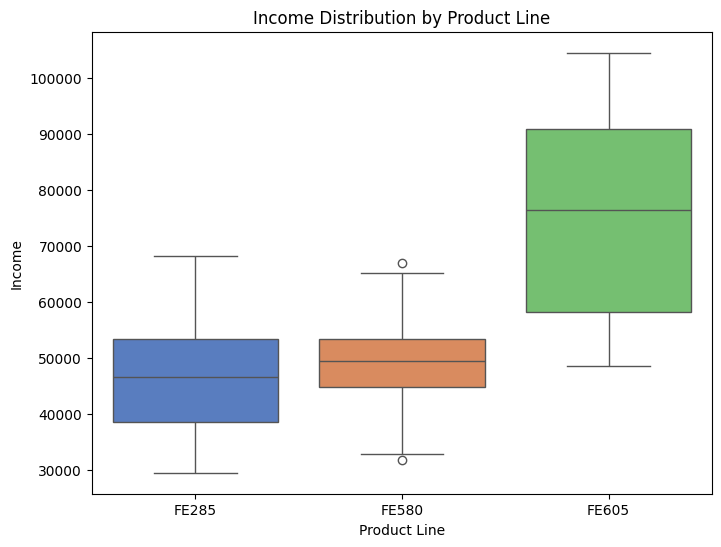

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Product', y='Income', data=fitness_df, palette='muted')
plt.title('Income Distribution by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Income')
plt.show()


FE605 is primarily purchased by customers with higher income levels, while FE285 caters to more budget-conscious buyers.

##Conclusion
###**Key Insights:**
####There is no significant difference in treadmill usage between partnered and single customers.
####Customers with higher fitness levels (4-5) plan to run/walk more miles weekly compared to those with lower fitness levels (1-3).
####There are significant differences in income across all three product lines, with FE605 attracting substantially higher-income customers than FE285 or FE580.
###**Marketing Implications:**
####Target FE605 to higher-income customers, and position FE285/FE580 for more budget-conscious and mid-market buyers respectively.
####Emphasize fitness-level benefits when marketing treadmills, particularly targeting customers with higher fitness levels.

###**Future Directions:**
####Explore customer satisfaction for different treadmill models.
####Investigate seasonal trends or promotional impacts.

###**Areas for Improvement:**
####Expand the dataset to include more demographic information.
####Analyze the role of treadmill features in influencing customer preferences.






